In [ ]:
Machine Learning
Dataset: Banknote Authentication
Reason: Clean binary classification, small enough for fast Colab runs, good for tree models and logistic
regression
url: https://archive.ics.uci.edu/ml/datasets/banknote+authentication
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.

In [2]:
# Install libraries and dependencies

!pip -q install ucimlrepo pyspark tensorflow scikit-learn seaborn matplotlib pandas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import tensorflow as tf

print ("libraries ready")

libraries ready


In [14]:
# Set up
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# Load dataset

banknote = fetch_ucirepo(id=267)  # UCI Banknote Authentication
X = banknote.data.features
y = banknote.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


Dataset shape: (1372, 5)

First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [15]:
# Try to find target column name robustly
target_col = y.columns[0]

In [16]:
# Basic statistical analysis

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df[target_col].value_counts())


Summary statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Target distribution:
class
0    762
1    610
Name: count, dtype: int64


visualization size set


/tmp/ipykernel_1136/903810330.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df.iloc[:, 0], ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_1136/903810330.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")


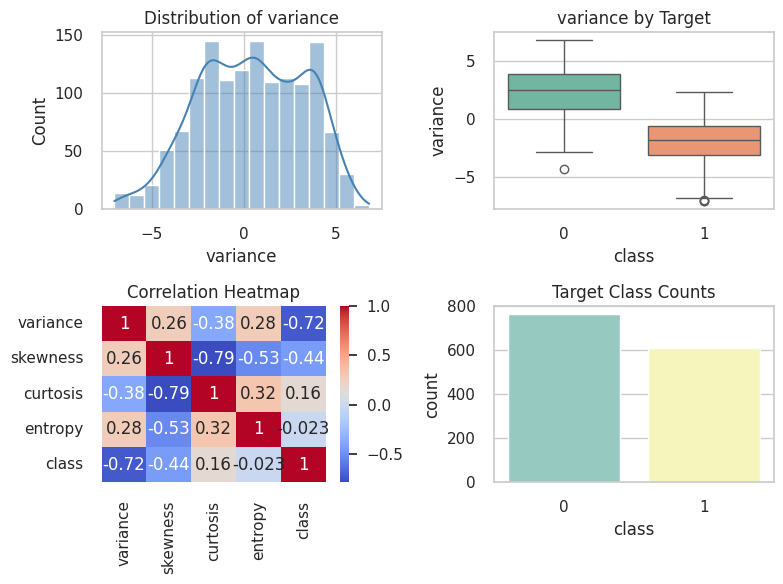

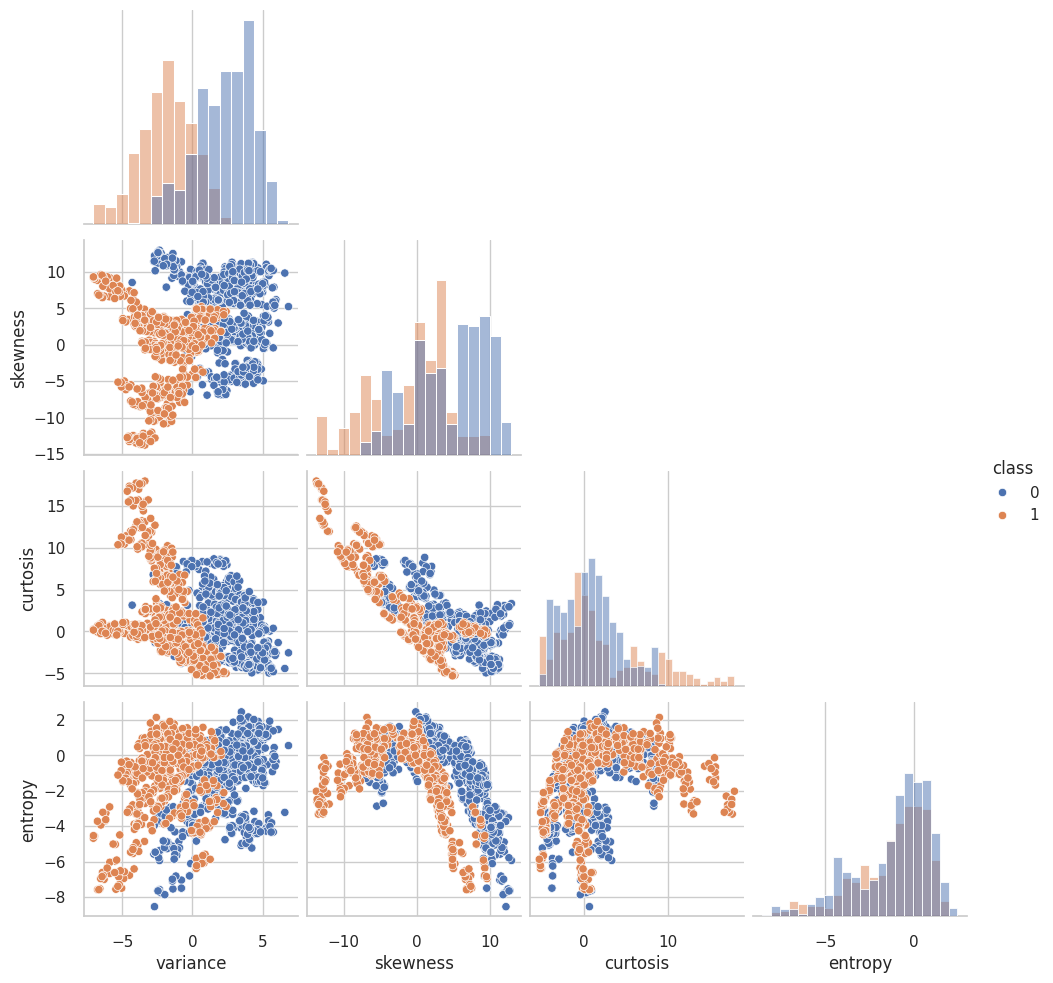

In [22]:
# Visualizations size
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
print("visualization size set")

# Visualizations
sns.histplot(df.iloc[:, 0], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title(f"Distribution of {df.columns[0]}")

sns.boxplot(x=df[target_col], y=df.iloc[:, 0], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title(f"{df.columns[0]} by Target")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Heatmap")

sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Target Class Counts")

plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df, hue=target_col, corner=True, diag_kind="hist")
plt.show()


In [26]:
# 5) Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y[target_col], test_size=0.2, random_state=42, stratify=y[target_col]
)



Logistic Regression
Accuracy: 0.9709090909090909
[[145   8]
 [  0 122]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       153
           1       0.94      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275


Decision Tree
Accuracy: 0.9927272727272727
[[151   2]
 [  0 122]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275


Random Forest
Accuracy: 0.9963636363636363
[[152   1]
 [  0 122]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1

/tmp/ipykernel_1136/1034765415.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


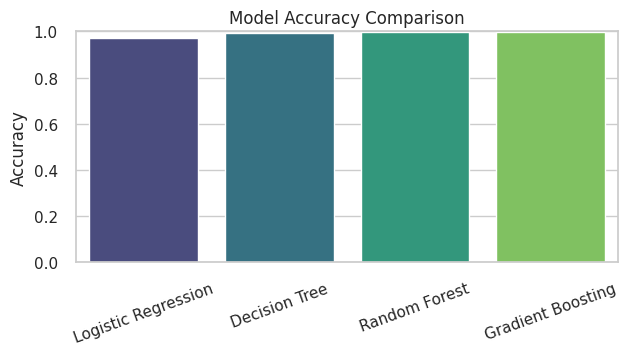

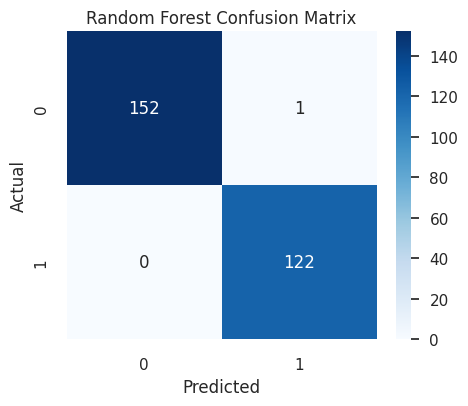

In [29]:
# Supervised Learning - Classification

# Logistic Regression
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
logit_model.fit(X_train, y_train)
logit_pred = logit_model.predict(X_test)

# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

def print_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

print_metrics("Logistic Regression", y_test, logit_pred)
print_metrics("Decision Tree", y_test, tree_pred)
print_metrics("Random Forest", y_test, rf_pred)
print_metrics("Gradient Boosting", y_test, gb_pred)

# Model comparison plot
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]
accuracies = [
    accuracy_score(y_test, logit_pred),
    accuracy_score(y_test, tree_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
]

plt.figure(figsize=(7, 3))
sns.barplot(x=model_names, y=accuracies, palette="viridis")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# Confusion matrix for best model (example: Random Forest)
best_pred = rf_pred
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Regression section (illustrative):
Predictions sample: [ 0.09864524  0.51719206  0.45012746 -0.1854612   0.04800005]


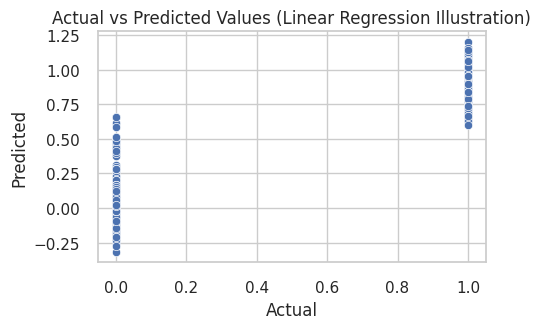

In [32]:
# Regression section

# Note: This dataset is naturally a classification dataset.
# The regression section below is illustrative only.
from sklearn.linear_model import LinearRegression

y_continuous = y[target_col].astype(float)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_continuous, test_size=0.2, random_state=42
)

reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg_model.fit(X_train_r, y_train_r)
reg_pred = reg_model.predict(X_test_r)

print("\nRegression section (illustrative):")
print("Predictions sample:", reg_pred[:5])

plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test_r, y=reg_pred)
plt.title("Actual vs Predicted Values (Linear Regression Illustration)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()



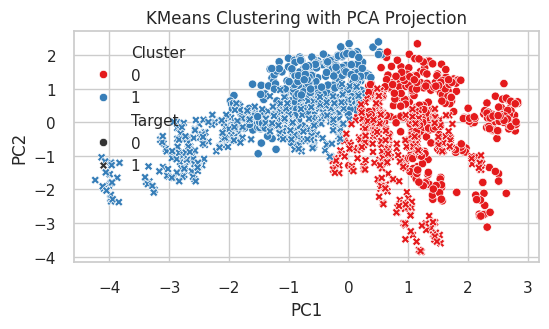

In [36]:
# Unsupervised Learning - Clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str),
    "Target": y[target_col].astype(str).values
})

plt.figure(figsize=(6, 3))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", style="Target", palette="Set1")
plt.title("KMeans Clustering with PCA Projection")
plt.show()



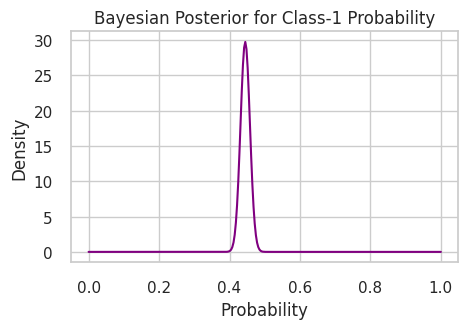

In [41]:
# Bayesian modeling section

# Note: A full Bayesian model is not necessary here, but this shows a simple Bayesian-style probability estimate.
from scipy.stats import beta

successes = int((y[target_col] == 1).sum())
failures = int((y[target_col] == 0).sum())
posterior_a = 1 + successes
posterior_b = 1 + failures

x_vals = np.linspace(0, 1, 300)
posterior_pdf = beta.pdf(x_vals, posterior_a, posterior_b)

plt.figure(figsize=(5, 3))
plt.plot(x_vals, posterior_pdf, color="purple")
plt.title("Bayesian Posterior for Class-1 Probability")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.show()



TensorFlow test accuracy: 1.0


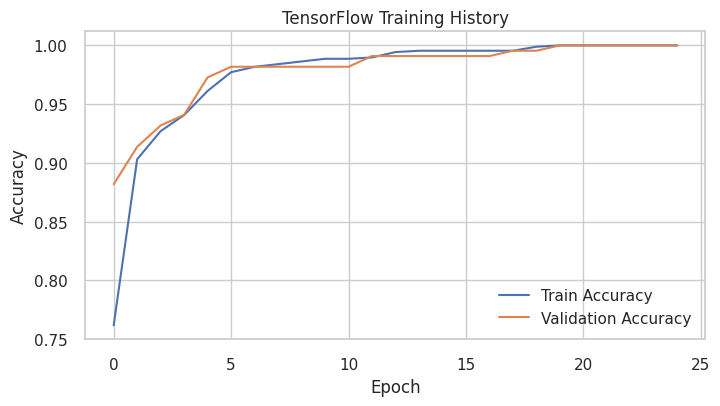

In [43]:
# TensorFlow model

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_scaled, y[target_col].values, test_size=0.2, random_state=42, stratify=y[target_col]
)

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = tf_model.fit(X_train_tf, y_train_tf, validation_split=0.2, epochs=25, batch_size=16, verbose=0)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print("\nTensorFlow test accuracy:", tf_acc)

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [48]:
# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler as SparkStandardScaler
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier as SparkDecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("BanknoteAuthentication").getOrCreate()

spark_df = spark.createDataFrame(df)

print("\nPySpark shape:")
print((spark_df.count(), len(spark_df.columns)))

feature_cols = [c for c in df.columns if c != target_col]

# Ensure target is binary numeric and rename to label BEFORE training
spark_df = spark_df.withColumn("label", col(target_col).cast("double")).drop(target_col)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_spark = SparkStandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

spark_train, spark_test = spark_df.randomSplit([0.8, 0.2], seed=42)

spark_lr = SparkLogisticRegression(featuresCol="features", labelCol="label", maxIter=50)
spark_dt = SparkDecisionTreeClassifier(featuresCol="features", labelCol="label")
spark_rf = SparkRandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
spark_gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

pipeline_lr = SparkPipeline(stages=[assembler, scaler_spark, spark_lr])
pipeline_dt = SparkPipeline(stages=[assembler, scaler_spark, spark_dt])
pipeline_rf = SparkPipeline(stages=[assembler, scaler_spark, spark_rf])
pipeline_gbt = SparkPipeline(stages=[assembler, scaler_spark, spark_gbt])

lr_model_spark = pipeline_lr.fit(spark_train)
dt_model_spark = pipeline_dt.fit(spark_train)
rf_model_spark = pipeline_rf.fit(spark_train)
gbt_model_spark = pipeline_gbt.fit(spark_train)

pred_lr = lr_model_spark.transform(spark_test)
pred_dt = dt_model_spark.transform(spark_test)
pred_rf = rf_model_spark.transform(spark_test)
pred_gbt = gbt_model_spark.transform(spark_test)

binary_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

print("\nPySpark AUC scores:")
print("Logistic Regression:", binary_evaluator.evaluate(pred_lr))
print("Decision Tree:", binary_evaluator.evaluate(pred_dt))
print("Random Forest:", binary_evaluator.evaluate(pred_rf))

print("\nGBT accuracy:")
print("Gradient Boosting:", accuracy_evaluator.evaluate(pred_gbt))

spark.stop()




PySpark shape:
(1372, 5)

PySpark AUC scores:
Logistic Regression: 0.9995692307692308
Decision Tree: 0.9843076923076924
Random Forest: 0.9976

GBT accuracy:
Gradient Boosting: 0.984313725490196


In [46]:
# End of notebook

print("\nCompleted banknote dataset workflow.")



Completed banknote dataset workflow.
